In [2]:
from autoenkoop import *
import torch
from torch.utils.data import DataLoader
import numpy as np
import pandas as pd
import os
import pydmd
from tqdm import tqdm
from matplotlib.colors import Normalize
import matplotlib.pyplot as plt

DEVICE = "cuda"

In [3]:
data_path = os.path.join("..", "data", "T1492_x1151_y1_z127_c2.npz")
center_dataset = True
train_test_split = 0.7
train_data, test_data, temp_mean = load_and_prepare_data(data_path, center_dataset, train_test_split)

In [4]:
full_data = np.concatenate((train_data, test_data), axis=0)

original_data = full_data + temp_mean
temp_mean_error = np.mean((full_data - temp_mean)**2, axis=(1,2,3))
(vx_min, vx_max), (vz_min, vz_max) = get_min_max(original_data)
vx_absmax = max(abs(vx_min), abs(vx_max))*0.2
vz_absmax = max(abs(vz_min), abs(vz_max))*0.2
norm_x = Normalize(vmin=-vx_absmax, vmax=+vx_absmax)
norm_z = Normalize(vmin=-vz_absmax, vmax=+vz_absmax)

In [5]:
PREDICTION_WINDOW = 100
window_offset_data = full_data[:-PREDICTION_WINDOW]

dataset_full = SimpleDataset(window_offset_data)

loader_full = DataLoader(dataset_full, batch_size=1, shuffle=False, num_workers=2, pin_memory=True, persistent_workers=True)

dataset_train = SimpleDataset(train_data)
loader_train = DataLoader(dataset_train, batch_size=4, shuffle=False)

full_data = np.moveaxis(full_data, -1, 1)

In [6]:
train_test_cutoff = int(full_data.shape[0]*0.7)
print(train_test_cutoff)

1045


In [7]:
def calculate_koopman(model, loader):
    Z = []
    with torch.no_grad():
        for x_t in loader:
            x_t = x_t.to(DEVICE)
            #encoded current state
            z_t = model.encoder(x_t) 
            Z.append(z_t.cpu().numpy())
    Z_all = np.vstack(Z).T
    dmd = pydmd.DMD(-1, forward_backward=False)
    dmd.fit(Z_all)
    K_star = (dmd.modes @ np.diag(dmd.eigs) @ np.linalg.pinv(dmd.modes)).real
    return K_star

L128_train_batch_nonorm_nobias_wlin1


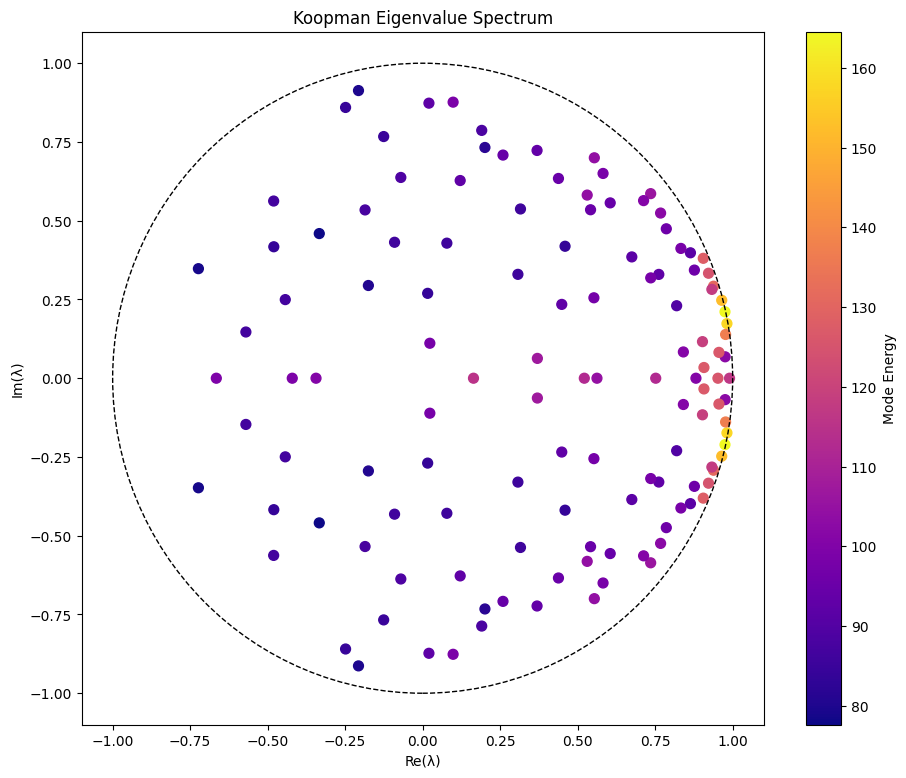

17


In [39]:
results_path = os.path.join("..", "results")
run_name_list = [
    #"L128_train_batch_nobias_wlin1",
    #"L128_train_layer_nobias_wlin1",
    #"L128_dmd_batch_norm_nobias_wlin0.1",
    #"L128_dmd_batch_norm_nobias_wlin1",
    "L128_train_batch_nonorm_nobias_wlin1",
    #"L16_train_batch_nonorm_nobias_wlin1",
    #"L16_dmd_batch_norm_nobias_wlin1",
    #"L128_dmd_batch_nonorm_nobias_wlin1",
    #"L128_dmd_batch_norm_nobias_wlin10",
    #"L128_dmd_batch_nobias_wlin100",
    #"L128_dmd_batch_nobias_wlin1000",
    #"L128_dmd_layer_nobias_wlin1",
    #"L128_dmd_layer_nobias_wlin10",
    #"L128_dmd_layer_nobias_wlin100",
    #"L128_dmd_layer_nobias_wlin1000",
    #"L128_train_batch_bias_wlin1",
    #"L128_train_layer_bias_wlin1",
    #"L128_dmd_batch_bias_wlin1",
    #"L128_dmd_layer_bias_wlin1",
]

CALCULATE_DMD_FOR_TRAINED = True
REDUCE_THRESHOLD = 0.0225

prediction_mse_windows = []

for run_name in run_name_list:
    print(run_name)
    run_path = os.path.join(results_path, "kae_experiments", run_name)
    
    hyperparam = run_name.split('_')
    
    LATENT_DIM = int(hyperparam[0][1:])
    koopman_type = hyperparam[1]
    norm_type = hyperparam[2]
    norm_latent = hyperparam[3] == "norm"
    use_bias = hyperparam[4] == "bias"

    model = ConvAutoencoder(latent_dim=LATENT_DIM, bias_terms=use_bias, norm_type=norm_type, norm_latent=norm_latent).to(DEVICE)
    
    model.load_state_dict(torch.load(os.path.join(run_path, "model.pt"), map_location=DEVICE))
    model.eval()

    if koopman_type == "dmd" or CALCULATE_DMD_FOR_TRAINED:
        koopman_type = "dmd"
        K = torch.tensor(calculate_koopman(model, loader_train), device=DEVICE, requires_grad=False)
        #lin_weights = torch.tensor(K, device=DEVICE, requires_grad=True)
        #linfunction = lambda z_t : torch.nn.functional.linear(z_t, K)
    else:
        #linfunction = lambda z_t : model.linear_dynamics(z_t)
        with torch.no_grad():
            K = model.linear_dynamics.weight.detach()#.cpu().numpy()
    
    K_numpy = K.cpu().numpy()
    eigvalues, eigvectors = get_sorted_eigen(K_numpy)
    eigenergies = eigenvalue_energies(model, eigvectors, DEVICE)
    plot_eigenvalue_spectrum(eigvalues, eigvectors, eigenergies)

    predictor, eigenvalues_reduced = get_multi_step_predictor(K, REDUCE_THRESHOLD)
    num_eigenvalues = eigenvalues_reduced.cpu().numpy().shape[0]
    print(num_eigenvalues)
    #break
    
    prediction_window_path = os.path.join(run_path,"pred_window"+str(PREDICTION_WINDOW)+"_mse_"+koopman_type+"_"+str(num_eigenvalues)+".npy")
    if os.path.exists(prediction_window_path):
        prediction_mse = np.load(prediction_window_path)
    else:
        prediction_mse = np.zeros((window_offset_data.shape[0], PREDICTION_WINDOW+1))
        with torch.no_grad():
            for j, x_t in tqdm(enumerate(loader_full), total=len(dataset_full)):
                x_t = x_t.to(DEVICE)
                z_t = model.encoder(x_t).squeeze(0)
                z_trajectory = predictor(z_t, PREDICTION_WINDOW)
                X_prediction = model.decoder(z_trajectory).cpu().numpy()
                #X_prediction = predict_window(x_t, model, linfunction, PREDICTION_WINDOW)
                mse_window = np.mean((full_data[j:j+PREDICTION_WINDOW+1] - X_prediction)**2, axis=(1,2,3))
                prediction_mse[j] = mse_window
        np.save(prediction_window_path[:-4], prediction_mse)
    prediction_mse_windows.append(prediction_mse)
            
    
    
    #
    #break

In [40]:
steady_tolerance = 0.0225

stable_values, stable_vectors, stable_energies = get_stable_modes(eigvalues, eigvectors, eigenergies, steady_tolerance, False)

17 stable mode explain: 17.94% of the energy


(0.9752976298332214+0.21086104214191437j) 	 0.9978315718854929
164.5357666015625


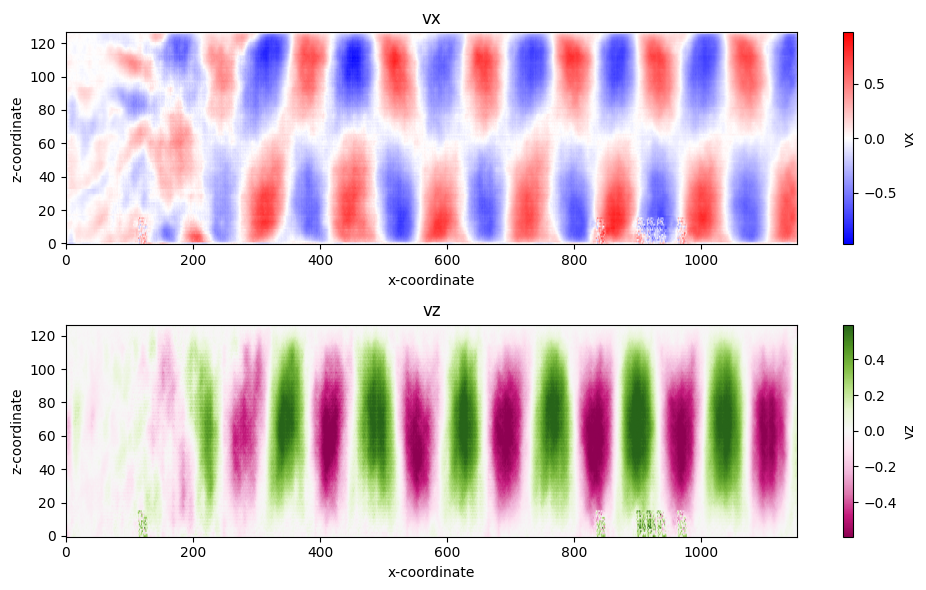

(0.981571614742279+0.17346255481243134j) 	 0.996780864979771
157.57041931152344


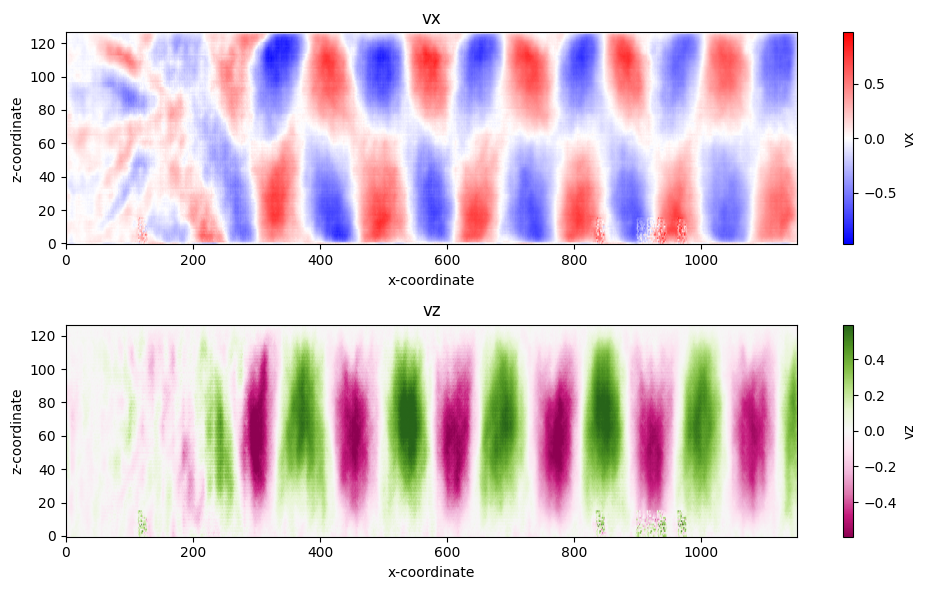

(0.9647168517112732+0.24749748408794403j) 	 0.9959586379993763
151.9964141845703


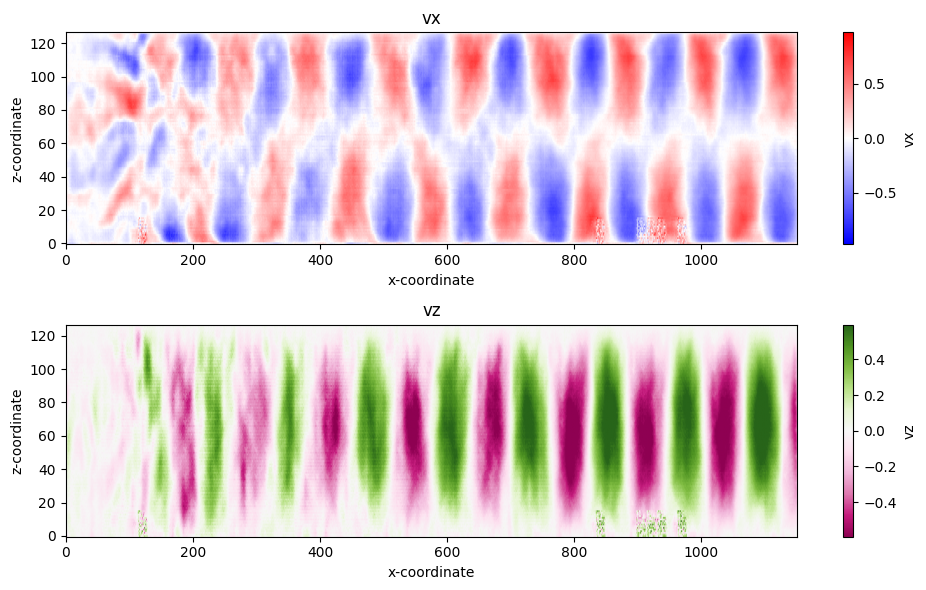

(0.9899695515632629+0j) 	 0.9899695515632629
116.32749938964844


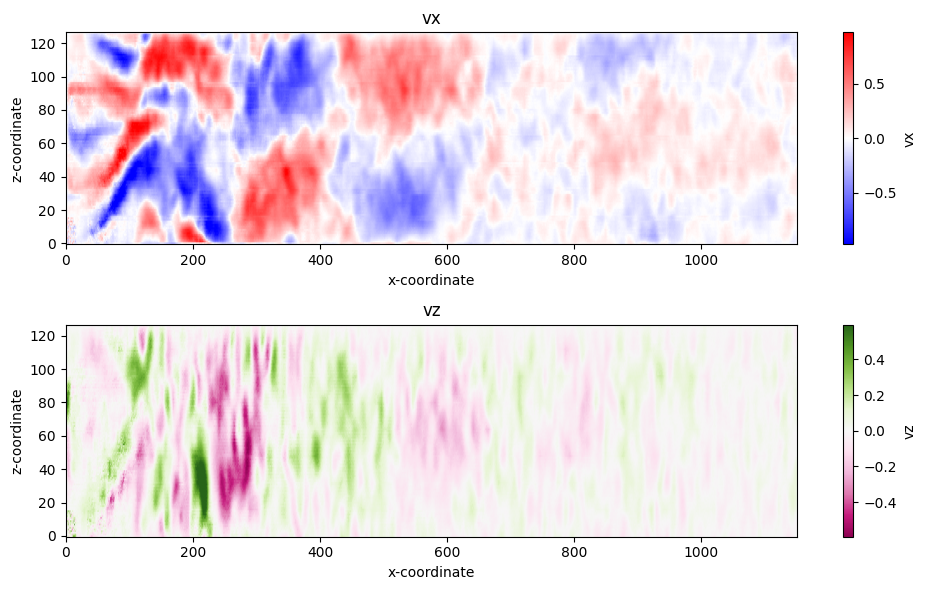

(0.9772526025772095+0.13890819251537323j) 	 0.9870755468513123
136.88975524902344


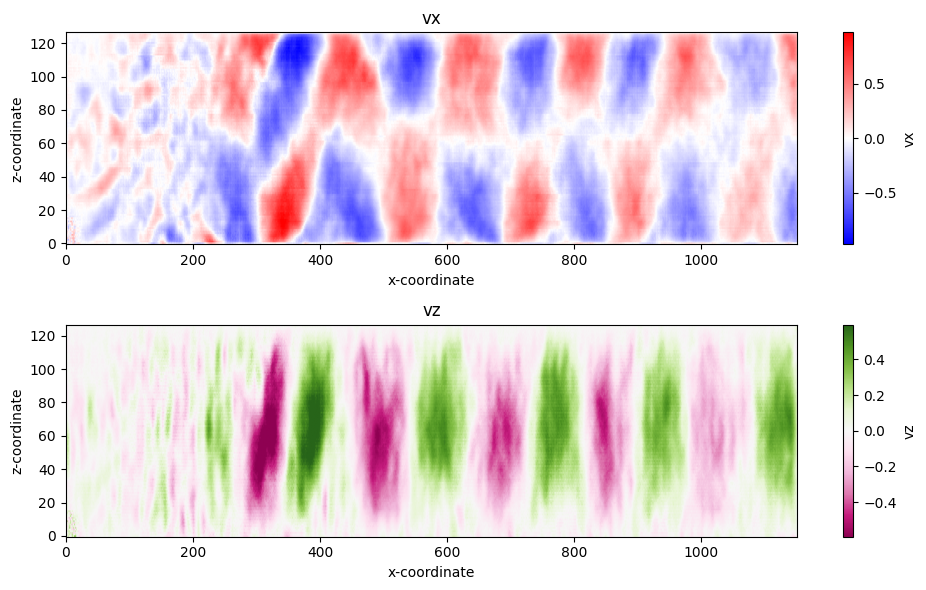

(0.938401460647583+0.2921085059642792j) 	 0.9828146725615163
130.78500366210938


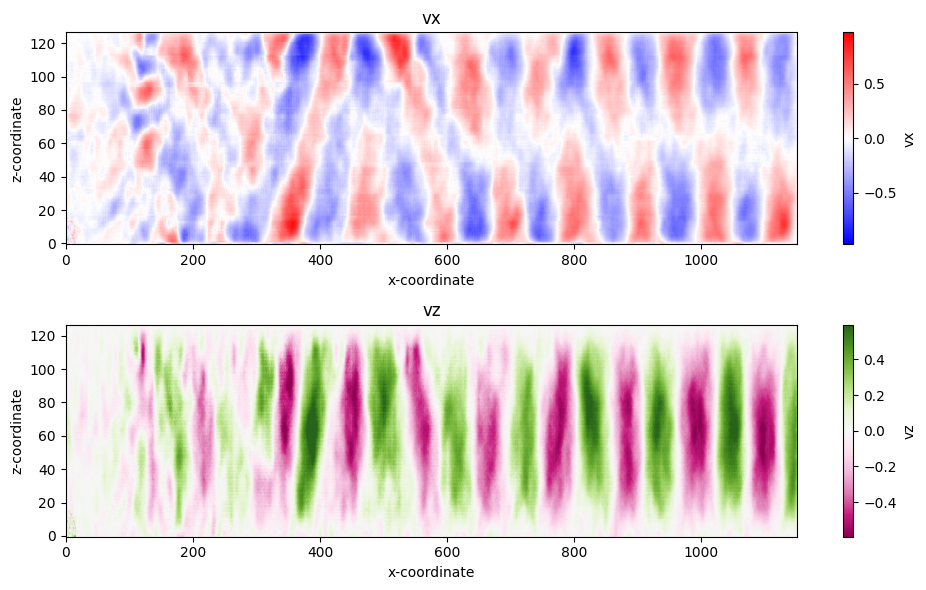

(0.9052273631095886+0.38070473074913025j) 	 0.9820247812235222
128.1749725341797


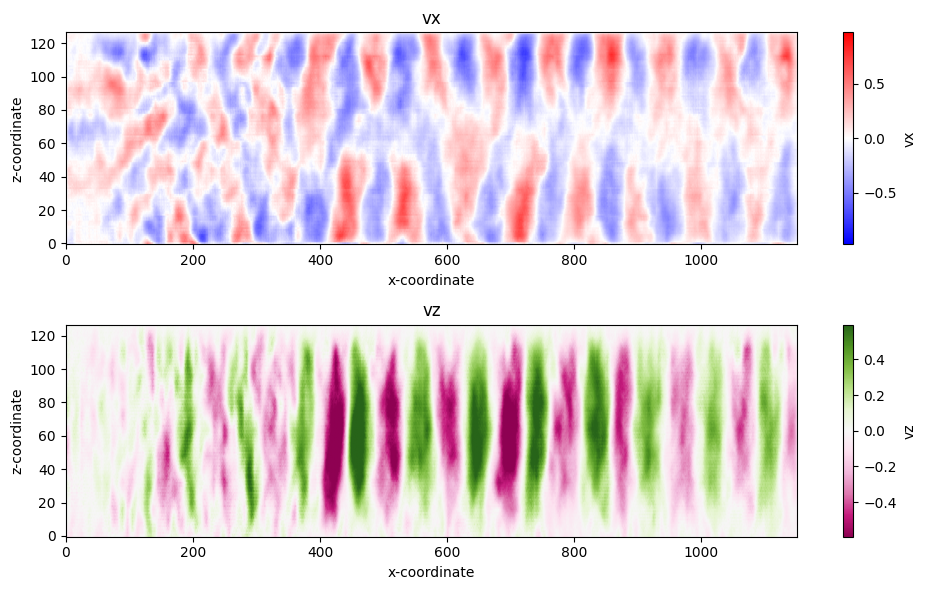

(0.9221636652946472+0.3332686424255371j) 	 0.9805375125989921
125.14783477783203


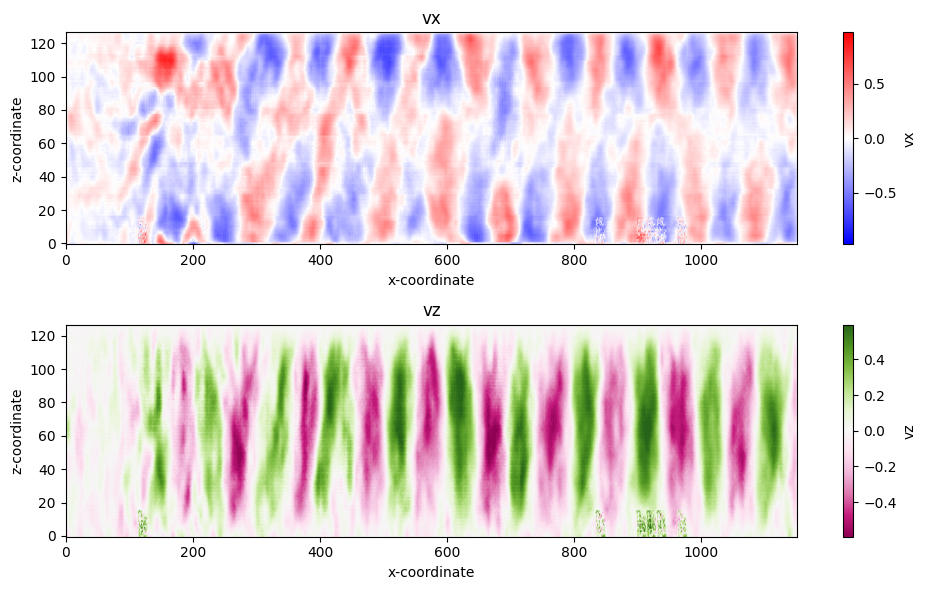

(0.9757496118545532+0.06799232959747314j) 	 0.9781156689872639
102.10464477539062


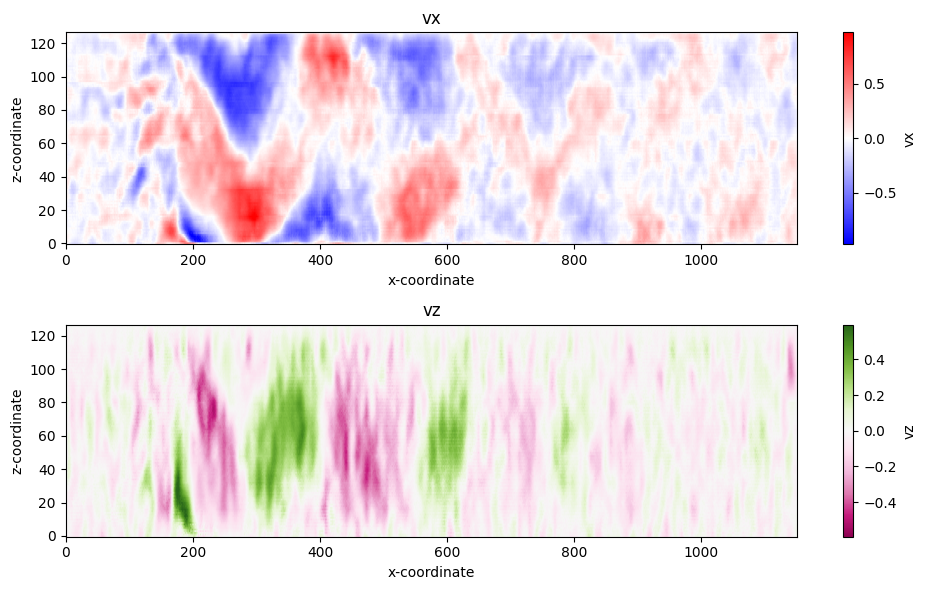

In [41]:
mode_values, mode_vectors, mode_energies = filter_pos_imag(stable_values, stable_vectors, stable_energies)
stable_structures = calculate_eigenmode_structures(mode_vectors, model, device=DEVICE)
for i, structure in enumerate(stable_structures):
    print(mode_values[i].item(),"\t", np.abs(mode_values[i].item()))
    print(mode_energies[i])
    vx = structure[0,:]
    vz = structure[1,:]
    plot_vx_vz(vx, vz, norm_x, norm_z)

In [ ]:
x_t = dataset_full[1147]
x_t = x_t.to(DEVICE).unsqueeze(0)
X_prediction = predict_window(x_t, model, linfunction, prediction_window)

In [ ]:
#example_index = 0
#
#vx = original_data[example_index, :, :, 0]
#vz = original_data[example_index, :, :, 1]
#
#plot_vx_vz(vx, vz, norm_x, norm_z)
#animate_trajectory(X_prediction+np.moveaxis(temp_mean, -1, 0), "prev_index_mode", norm_x, norm_z)

In [28]:
global_mse_list = []

for i, windowed_mse in enumerate(prediction_mse_windows):
    #if run_name_list[i] != "L128_e300_lamlin10_train":
    global_mse_list.append(np.mean(windowed_mse, 0))

In [29]:
train_mean_mse = []
test_mean_mse = []

for i, windowed_mse in enumerate(prediction_mse_windows):
    #if run_name_list[i] != "L128_e300_lamlin10_train":
    train_mean_mse.append(np.mean(windowed_mse[:train_test_cutoff], 0))
    test_mean_mse.append(np.mean(windowed_mse[train_test_cutoff:], 0))

In [30]:
mean_mse_list = []

for i, windowed_mse in enumerate(prediction_mse_windows):
    #if run_name_list[i] != "L128_e300_lamlin10_train":
    mean_mse_list.append(np.mean(windowed_mse, 1))

In [31]:
train_test_name_list = [name+" TRAIN" for name in run_name_list]+[name+" TEST" for name in run_name_list]

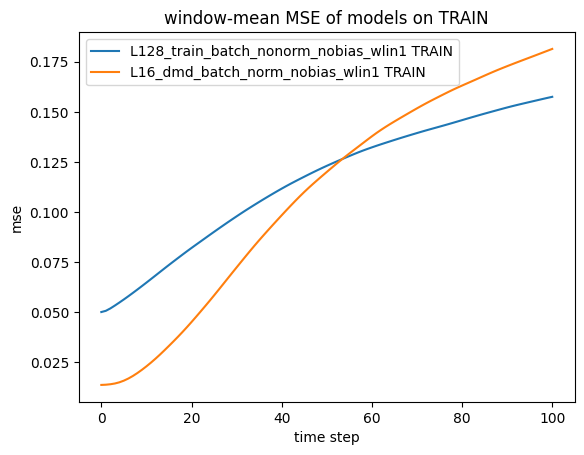

In [32]:
plot_evolution(train_mean_mse, [name+" TRAIN" for name in run_name_list], "window-mean MSE of models on TRAIN", "time step", "mse")
plt.yscale("linear")

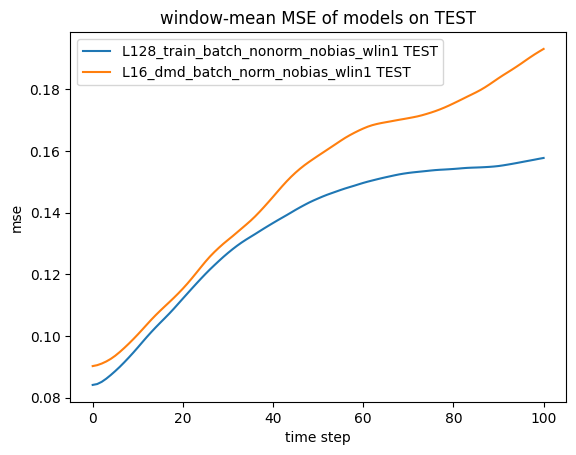

In [33]:
plot_evolution(test_mean_mse, [name+" TEST" for name in run_name_list], "window-mean MSE of models on TEST", "time step", "mse")
plt.yscale("linear")

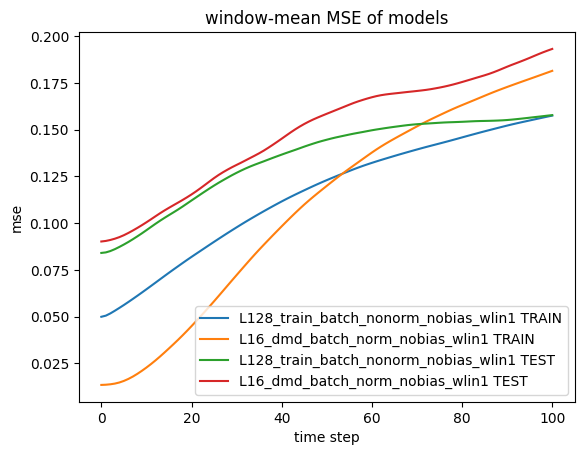

In [36]:
plot_evolution(train_mean_mse + test_mean_mse, train_test_name_list, "window-mean MSE of models", "time step", "mse")
plt.yscale("linear")

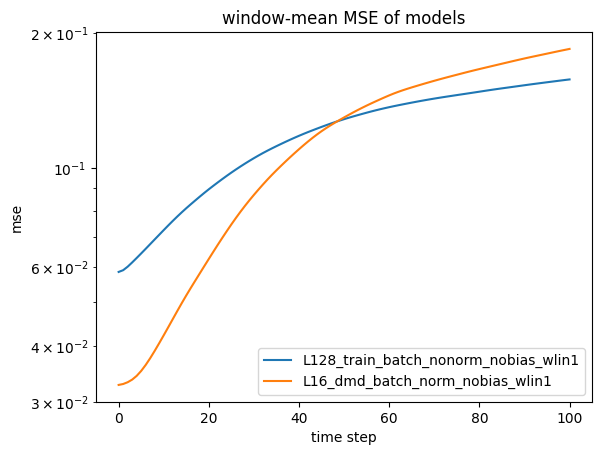

In [37]:
plot_evolution(global_mse_list, run_name_list, "window-mean MSE of models", "time step", "mse")

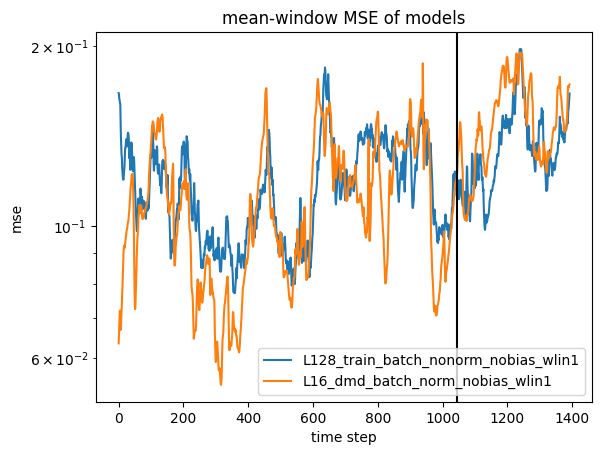

In [38]:
plot_evolution(mean_mse_list, run_name_list, "mean-window MSE of models", "time step", "mse")
#plt.yscale("linear")
plt.vlines(train_test_cutoff, 0.05, 0.5, colors=["black"])


In [ ]:
plot_evolution(mean_mse_list+[temp_mean_error[:1393]], run_name_list+["temp_mean_error"], "mean-window MSE of models", "time step", "mse")
plt.yscale("linear")
#plt.vlines(train_test_cutoff, 0, 2, colors=["black"])

In [ ]:
mean_mse_list[0][1147]

In [ ]:
np.argmax(mean_mse_list[0])